# DeTeCtive AI Density Event Study DID

## Research Question

How did the release of ChatGPT on November 30, 2022 affect Kickstarter funding outcomes for campaigns with high AI-text density in their project updates?

## Design

This notebook estimates a dynamic Difference-in-Differences event study. Treatment is defined at the project level from DeTeCtive sentence-level AI scores in Kickstarter updates. Time is binned relative to November 2022 so the pre-period bin immediately before the shock, `Q-1`, is the omitted reference category.

The key diagnostic is the pre-trend: interaction coefficients before ChatGPT should be close to zero if high-AI and low-AI campaigns were evolving similarly before the release.

In [ ]:
# Step 0: Imports, paths, and global settings
from pathlib import Path
import ast
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk')


def repo_root() -> Path:
    """Find the repository root from a notebook launched in either repo root or src/analysis."""
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / 'data').is_dir() and (p / 'src').is_dir():
            return p
        p = p.parent
    return Path.cwd().resolve()


ROOT = repo_root()
BASELINE_PKL = ROOT / 'data' / 'processed' / 'final_with_deberta_ai_score_20251003_151656.pkl'
UPDATES_CSV = ROOT / 'data' / 'analysis' / 'detective' / 'all_updates_analyzed_detective.csv'
COMMENTS_CSV = ROOT / 'data' / 'analysis' / 'all_comments_analyzed.csv'
CHATGPT_RELEASE = pd.Timestamp('2022-11-30')
CHATGPT_MONTH = pd.Timestamp('2022-11-01')

print(f'Repo root: {ROOT}')
print(f'Baseline file: {BASELINE_PKL}')
print(f'DeTeCtive updates file: {UPDATES_CSV}')
print(f'Analyzed comments file: {COMMENTS_CSV}')

ModuleNotFoundError: No module named 'statsmodels'

## 1. Data Prep and Imputation

Load the baseline campaign file, build the outcome and controls, normalize categories, merge DeTeCtive update metrics for AI density, and merge analyzed comment sentiment for the mediation pathway.

In [2]:
# Step 1A: Load baseline campaigns and create outcome/control variables
if not BASELINE_PKL.is_file():
    raise FileNotFoundError(f'Missing baseline pickle: {BASELINE_PKL}')

df = pd.read_pickle(BASELINE_PKL)
print(f'Loaded {len(df):,} campaigns')


def first_existing(columns, candidates, required=True):
    """Return the first candidate column present in a dataframe."""
    for col in candidates:
        if col in columns:
            return col
    if required:
        raise KeyError(f'None of these columns were found: {candidates}')
    return None


project_id_col = first_existing(df.columns, ['project_id', 'id', 'projectId'])
df['project_id'] = df[project_id_col].astype(str)

# Goal imputation follows the earlier DID notebook for Indiegogo rows with funding percentages.
if {'platform', 'goal', 'pledged', 'funds_raised_percent'}.issubset(df.columns):
    impute_mask = (
        (df['platform'] == 'Indiegogo')
        & df['goal'].isna()
        & df['pledged'].notna()
        & (pd.to_numeric(df['pledged'], errors='coerce') > 0)
        & df['funds_raised_percent'].notna()
        & (pd.to_numeric(df['funds_raised_percent'], errors='coerce') > 0)
    )
    df.loc[impute_mask, 'goal'] = df.loc[impute_mask, 'pledged'] / (df.loc[impute_mask, 'funds_raised_percent'] / 100)
    print(f'Imputed {impute_mask.sum():,} missing goals')

pledged_col = first_existing(
    df.columns,
    ['pledged_amount(usd)', 'pledged_amount_usd', 'pledged_usd', 'usd_pledged', 'converted_pledged_amount', 'pledged'],
)
df['pledged_amount_usd'] = pd.to_numeric(df[pledged_col], errors='coerce')

# If pledged is unavailable but funding percentages are present, reconstruct pledged from goal and percent funded.
if df['pledged_amount_usd'].isna().all() and {'goal', 'percent_funded', 'funds_raised_percent', 'platform'}.issubset(df.columns):
    df['pledged_amount_usd'] = np.nan
    ks_mask = df['platform'] == 'Kickstarter'
    ig_mask = df['platform'] == 'Indiegogo'
    df.loc[ks_mask, 'pledged_amount_usd'] = df.loc[ks_mask, 'goal'] * df.loc[ks_mask, 'percent_funded'] / 100
    df.loc[ig_mask, 'pledged_amount_usd'] = df.loc[ig_mask, 'goal'] * df.loc[ig_mask, 'funds_raised_percent'] / 100

df['goal'] = pd.to_numeric(df['goal'], errors='coerce')
df['log_pledged_amount'] = np.log(df['pledged_amount_usd'].clip(lower=0).fillna(0) + 1)
df['log_goal'] = np.log(df['goal'].clip(lower=0) + 1)
df['word_count'] = pd.to_numeric(df.get('word_count'), errors='coerce')
df['text_quality'] = pd.to_numeric(df.get('text_quality'), errors='coerce')

print(df[['project_id', 'pledged_amount_usd', 'log_pledged_amount', 'goal', 'log_goal']].head())

Loaded 64,488 campaigns
Imputed 14,223 missing goals
   project_id  pledged_amount_usd  log_pledged_amount     goal  log_goal
0   542949574          711.000000            6.568078    500.0  6.216606
1    76740313         3333.000000            8.111928   3000.0  8.006701
2  1118160310          139.327562            4.943979  10000.0  9.210440
3  1978410442           35.589108            3.599751    275.0  5.620401
4  1368557852         7680.615368            8.946585   6000.0  8.699681


In [3]:
# Step 1B: Clean and map platform-specific categories into category_unified
ks_mapping = {
    'Illustration': 'Creative_Visual_Arts', 'Digital Art': 'Creative_Visual_Arts', 'Art': 'Creative_Visual_Arts',
    'Animation': 'Creative_Visual_Arts', 'Painting': 'Creative_Visual_Arts', 'Sculpture': 'Creative_Visual_Arts',
    'Photography': 'Creative_Visual_Arts', 'Mixed Media': 'Creative_Visual_Arts', 'Design': 'Creative_Visual_Arts',
    'Fine Art': 'Creative_Visual_Arts', 'Public Art': 'Creative_Visual_Arts',
    'Comic Books': 'Publishing_Writing', 'Graphic Novels': 'Publishing_Writing', 'Fiction': 'Publishing_Writing',
    'Nonfiction': 'Publishing_Writing', 'Anthologies': 'Publishing_Writing', 'Zines': 'Publishing_Writing',
    'Poetry': 'Publishing_Writing', 'Literature': 'Publishing_Writing', 'Academic': 'Publishing_Writing',
    'Journals': 'Publishing_Writing', 'Comics': 'Publishing_Writing',
    'Product Design': 'Technology_Hardware', 'Hardware': 'Technology_Hardware', 'Apps': 'Technology_Hardware',
    'Gadgets': 'Technology_Hardware', 'DIY Electronics': 'Technology_Hardware', 'Wearables': 'Technology_Hardware',
    'Gaming Hardware': 'Technology_Hardware', 'Robotics': 'Technology_Hardware', '3D Printing': 'Technology_Hardware',
    'Software': 'Technology_Hardware', 'Technology': 'Technology_Hardware',
    'Playing Cards': 'Games_Toys', 'Tabletop Games': 'Games_Toys', 'Video Games': 'Games_Toys',
    'Mobile Games': 'Games_Toys', 'Live Games': 'Games_Toys', 'Puzzles': 'Games_Toys', 'Toys': 'Games_Toys', 'Games': 'Games_Toys',
    'Shorts': 'Film_Music_Performance', 'Drama': 'Film_Music_Performance', 'Comedy': 'Film_Music_Performance',
    'Horror': 'Film_Music_Performance', 'Documentary': 'Film_Music_Performance', 'Music': 'Film_Music_Performance',
    'Rock': 'Film_Music_Performance', 'Hip-Hop': 'Film_Music_Performance', 'Pop': 'Film_Music_Performance',
    'Jazz': 'Film_Music_Performance', 'Classical Music': 'Film_Music_Performance', 'Country & Folk': 'Film_Music_Performance',
    'Electronic Music': 'Film_Music_Performance', 'Indie Rock': 'Film_Music_Performance', 'Theater': 'Film_Music_Performance',
    'Performance Art': 'Film_Music_Performance', 'Festivals': 'Film_Music_Performance', 'Film & Video': 'Film_Music_Performance',
    'Musical': 'Film_Music_Performance', 'Webseries': 'Film_Music_Performance', 'Television': 'Film_Music_Performance',
    'Radio & Podcasts': 'Film_Music_Performance', 'Audio': 'Film_Music_Performance', 'Narrative Film': 'Film_Music_Performance',
    'Dance': 'Film_Music_Performance', 'Sound': 'Film_Music_Performance', 'Blues': 'Film_Music_Performance',
    'World Music': 'Film_Music_Performance', 'Latin': 'Film_Music_Performance', 'Metal': 'Film_Music_Performance', 'Punk': 'Film_Music_Performance',
    'Restaurants': 'Food_Lifestyle', 'Drinks': 'Food_Lifestyle', 'Food Trucks': 'Food_Lifestyle', 'Vegan': 'Food_Lifestyle',
    'Cookbooks': 'Food_Lifestyle', 'Candles': 'Food_Lifestyle', 'Fashion': 'Food_Lifestyle', 'Apparel': 'Food_Lifestyle',
    'Accessories': 'Food_Lifestyle', 'Jewelry': 'Food_Lifestyle', 'Footwear': 'Food_Lifestyle', 'Cosmetics': 'Food_Lifestyle', 'Food': 'Food_Lifestyle',
    'Community Gardens': 'Community_Education', 'Faith': 'Community_Education', 'Social Practice': 'Community_Education',
    'Events': 'Community_Education', 'Community': 'Community_Education',
}

ig_mapping = {
    'Art': 'Creative_Visual_Arts', 'Photography': 'Creative_Visual_Arts', 'Dance & Theater': 'Creative_Visual_Arts',
    'Web Series & TV Shows': 'Creative_Visual_Arts', 'Comics': 'Publishing_Writing',
    'Writing & Publishing': 'Publishing_Writing', 'Blogs/Podcasts/Vlogs': 'Publishing_Writing',
    'Productivity': 'Technology_Hardware', 'Phones & Accessories': 'Technology_Hardware', 'Energy & Green Tech': 'Technology_Hardware',
    'Smart Home': 'Technology_Hardware', 'Computers': 'Technology_Hardware', 'IoT': 'Technology_Hardware', 'Security': 'Technology_Hardware',
    'Drones': 'Technology_Hardware', 'VR/AR': 'Technology_Hardware', 'Transportation': 'Technology_Hardware',
    'Tabletop Games': 'Games_Toys', 'Video Games': 'Games_Toys', 'Toys': 'Games_Toys',
    'Film': 'Film_Music_Performance', 'Music': 'Film_Music_Performance', 'Audio': 'Film_Music_Performance',
    'Web Series & TV': 'Film_Music_Performance', 'Food & Beverages': 'Food_Lifestyle',
    'Fashion & Wearables': 'Food_Lifestyle', 'Home': 'Food_Lifestyle', 'Beauty': 'Food_Lifestyle',
    'Health & Fitness': 'Food_Lifestyle', 'Wellness': 'Food_Lifestyle', 'Education': 'Community_Education',
    'Human Rights': 'Community_Education', 'Local Businesses': 'Community_Education', 'Environment': 'Community_Education',
    'Social Innovations': 'Community_Education', 'Culture': 'Community_Education',
}

df['category_unified'] = 'Other'
if 'platform' in df.columns:
    ks_mask = df['platform'].eq('Kickstarter')
    ig_mask = df['platform'].eq('Indiegogo')
else:
    ks_mask = pd.Series(True, index=df.index)
    ig_mask = pd.Series(False, index=df.index)

category_col = first_existing(df.columns, ['category_name', 'category', 'category_slug'], required=False)
ig_category_col = first_existing(df.columns, ['category_parent_name', 'category_name', 'category'], required=False)
if category_col is not None:
    df.loc[ks_mask, 'category_unified'] = df.loc[ks_mask, category_col].map(ks_mapping).fillna('Other')
if ig_category_col is not None:
    df.loc[ig_mask, 'category_unified'] = df.loc[ig_mask, ig_category_col].map(ig_mapping).fillna('Other')

print(df['category_unified'].value_counts(dropna=False))

category_unified
Film_Music_Performance    14575
Other                     11240
Publishing_Writing         9461
Creative_Visual_Arts       7353
Technology_Hardware        7332
Food_Lifestyle             7036
Games_Toys                 5788
Community_Education        1703
Name: count, dtype: int64


In [5]:
# Step 1C: Load DeTeCtive update metrics for treatment and analyzed comments for mediation
if not UPDATES_CSV.is_file():
    raise FileNotFoundError(f'Missing DeTeCtive updates CSV: {UPDATES_CSV}')
if not COMMENTS_CSV.is_file():
    raise FileNotFoundError(f'Missing analyzed comments CSV: {COMMENTS_CSV}')

updates = pd.read_csv(UPDATES_CSV)
updates['project_id'] = updates['project_id'].astype(str)

def parse_score_list(value):
    """Convert stringified DeTeCtive sentence scores to a list of floats."""
    if isinstance(value, list):
        raw = value
    elif pd.isna(value):
        raw = []
    else:
        try:
            raw = ast.literal_eval(str(value))
        except (ValueError, SyntaxError):
            raw = []
    return [float(x) for x in raw if pd.notna(x)]

updates['ai_scores_sentences_parsed'] = updates['ai_scores_sentences'].apply(parse_score_list)
updates['n_sentences_scored'] = updates['ai_scores_sentences_parsed'].str.len()
updates['ai_density'] = updates['ai_scores_sentences_parsed'].apply(
    lambda scores: np.mean(np.array(scores) > 0.70) if len(scores) else np.nan
)

update_metrics = (
    updates.groupby('project_id', as_index=False)
    .agg(
        ai_density=('ai_density', 'mean'),
        update_count=('project_id', 'size'),
        scored_sentence_count=('n_sentences_scored', 'sum'),
    )
)

comments = pd.read_csv(COMMENTS_CSV)
comments['project_id'] = comments['project_id'].astype(str)
comment_sentiment_col = first_existing(
    comments.columns,
    ['vader_compound', 'compound', 'sentiment_compound', 'compound_sentiment'],
    required=False,
)
if comment_sentiment_col is None:
    raise KeyError(
        "No comment sentiment column found. Expected one of: "
        "vader_compound, compound, sentiment_compound, compound_sentiment."
    )
comments['comment_sentiment'] = pd.to_numeric(comments[comment_sentiment_col], errors='coerce')

comment_metrics = (
    comments.groupby('project_id', as_index=False)
    .agg(
        comment_sentiment=('comment_sentiment', 'mean'),
        comment_count=('project_id', 'size'),
    )
)

df = df.merge(update_metrics, on='project_id', how='left', validate='m:1')
df = df.merge(comment_metrics, on='project_id', how='left', validate='m:1')

print(f'Loaded {len(updates):,} DeTeCtive updates for {updates.project_id.nunique():,} projects')
print(f'Loaded {len(comments):,} analyzed comments for {comments.project_id.nunique():,} projects')
print(f'Matched update AI density to {df.ai_density.notna().sum():,} baseline rows')
print(f'Matched comment sentiment to {df.comment_sentiment.notna().sum():,} baseline rows')

pd.concat(
    {
        'updates': update_metrics.describe(include='all').T,
        'comments': comment_metrics.describe(include='all').T,
    },
    names=['source', 'metric'],
)

Loaded 298,905 DeTeCtive updates for 29,337 projects
Loaded 1,032,352 analyzed comments for 23,879 projects
Matched update AI density to 28,201 baseline rows
Matched comment sentiment to 23,879 baseline rows


count unique        top freq       mean  \
source   metric                                                             
updates  project_id               29337  29337  999788375    1        NaN   
         ai_density             28201.0    NaN        NaN  NaN   0.548632   
         update_count           29337.0    NaN        NaN  NaN   10.18867   
         scored_sentence_count  29337.0    NaN        NaN  NaN  98.983536   
comments project_id               23879  23879  999788375    1        NaN   
         comment_sentiment      23879.0    NaN        NaN  NaN    0.40205   
         comment_count          23879.0    NaN        NaN  NaN  43.232631   

                                       std     min       25%       50%  \
source   metric                                                          
updates  project_id                    NaN     NaN       NaN       NaN   
         ai_density               0.174734     0.0   0.44537  0.541109   
         update_count            10.417051     1.0       3.0       7.0   
         scored_sentence_count  170.169147     0.0      16.0      48.0   
comments project_id                    NaN     NaN       NaN       NaN   
         comment_sentiment        0.262615 -0.9931  0.235987    0.4005   
         comment_count          143.527983     1.0       2.0       7.0   

                                     75%     max  
source   metric                                   
updates  project_id                  NaN     NaN  
         ai_density             0.653333     1.0  
         update_count               14.0   407.0  
         scored_sentence_count     116.0  6038.0  
comments project_id                  NaN     NaN  
         comment_sentiment         0.575  0.9983  
         comment_count              28.0  4332.0

## 2. Time Binning for the Event Study

`months_from_gpt` measures distance from November 2022, where November 2022 is `0`. The event-study bins are coarse enough to keep each cell populated. `Q-1`, the three months immediately before November 2022, is the omitted reference category.

In [6]:
# Step 2: Parse dates, build month distance, and assign ordered event-study bins
def clean_timezone(value):
    if pd.isna(value):
        return pd.NaT
    return re.sub(r'[+-]\\d{2}:\\d{2}$', '', str(value))

df['created_at_parsed'] = pd.to_datetime(df['created_at'].apply(clean_timezone), errors='coerce')
df['year'] = df['created_at_parsed'].dt.year
df['month'] = df['created_at_parsed'].dt.month
df['months_from_gpt'] = (df['year'] - CHATGPT_MONTH.year) * 12 + (df['month'] - CHATGPT_MONTH.month)
df['PostGPT'] = (df['created_at_parsed'] >= CHATGPT_RELEASE).astype(int)

EVENT_BIN_ORDER = ['Q-3', 'Q-2', 'Q-1', 'Q0', 'Q+1', 'Q+2', 'Q+3']

def assign_event_bin(month_distance):
    if pd.isna(month_distance):
        return np.nan
    if month_distance <= -7:
        return 'Q-3'
    if -6 <= month_distance <= -4:
        return 'Q-2'
    if -3 <= month_distance <= -1:
        return 'Q-1'
    if 0 <= month_distance <= 2:
        return 'Q0'
    if 3 <= month_distance <= 5:
        return 'Q+1'
    if 6 <= month_distance <= 8:
        return 'Q+2'
    return 'Q+3'

df['time_bin'] = pd.Categorical(
    df['months_from_gpt'].apply(assign_event_bin),
    categories=EVENT_BIN_ORDER,
    ordered=True,
)

print('Event-study bin counts:')
print(df['time_bin'].value_counts().reindex(EVENT_BIN_ORDER))
print('\nDate range:', df['created_at_parsed'].min(), 'to', df['created_at_parsed'].max())

Event-study bin counts:
time_bin
Q-3     6459
Q-2     3555
Q-1     3732
Q0      3469
Q+1     4165
Q+2     4050
Q+3    21801
Name: count, dtype: int64

Date range: 2021-11-01 00:42:52 to 2024-11-29 22:02:44


## 3. Define Treatment

`High_AI` is set to 1 when a project's average update-level AI density is above 0.50. The top-quartile treatment is also computed for sensitivity checks.

In [20]:
# Step 3: Define treatment and analysis sample (Extremes Approach)
REQUIRE_ANALYZED_UPDATES = True

# 1. Build the sample mask to drop invalid rows
sample_mask = (
    df['created_at_parsed'].notna()
    & df['log_pledged_amount'].notna()
    & df['log_goal'].notna()
    & df['text_quality'].notna()
    & df['word_count'].notna()
    & df['category_unified'].notna()
    & df['time_bin'].notna()
)
if 'platform' in df.columns:
    sample_mask &= df['platform'].eq('Kickstarter')
if REQUIRE_ANALYZED_UPDATES:
    sample_mask &= df['ai_density'].notna()

# 2. Apply the mask to create the base analysis sample
df_base = df.loc[sample_mask].copy()

# 3. Calculate both the 25th and 75th percentiles on the clean data
ai_q75 = df_base['ai_density'].quantile(0.75)
ai_q25 = df_base['ai_density'].quantile(0.25)

# 4. Filter for only the extremes (Drop the middle 50%)
extremes_mask = (df_base['ai_density'] >= ai_q75) | (df_base['ai_density'] <= ai_q25)
df_analysis = df_base.loc[extremes_mask].copy()

# 5. Define Treatment (1 for Top Quartile, 0 for Bottom Quartile)
df_analysis['High_AI'] = (df_analysis['ai_density'] >= ai_q75).astype(int)

# 6. Print diagnostics
print(f'Original valid projects: {len(df_base):,}')
print(f'Analysis sample (Extremes only): {len(df_analysis):,} projects')
print(f'AI density thresholds -> Bottom 25%: <= {ai_q25:.3f} | Top 25%: >= {ai_q75:.3f}')
print('\nTreatment counts:')
print(df_analysis['High_AI'].value_counts().rename(index={0: 'Low_AI (Bottom 25%)', 1: 'High_AI (Top 25%)'}))
print('\nTime bin x treatment counts:')
print(pd.crosstab(df_analysis['time_bin'], df_analysis['High_AI']))

Original valid projects: 26,395
Analysis sample (Extremes only): 13,224 projects
AI density thresholds -> Bottom 25%: <= 0.446 | Top 25%: >= 0.650

Treatment counts:
High_AI
High_AI (Top 25%)      6625
Low_AI (Bottom 25%)    6599
Name: count, dtype: int64

Time bin x treatment counts:
High_AI      0     1
time_bin            
Q-3        920   763
Q-2        522   369
Q-1        536   445
Q0         487   456
Q+1        571   576
Q+2        572   558
Q+3       2991  3458


## 4. Dynamic DID Event Study Regression

The regression interacts `High_AI` with the event-time bins. `Q-1` is the omitted category, so each interaction coefficient is interpreted relative to the high-vs-low AI difference in the months immediately before ChatGPT.

In [24]:
# Step 4: Fit the event-study model with HC3 robust standard errors
event_formula = (
    "log_pledged_amount ~ High_AI * C(time_bin, Treatment(reference='Q-1')) "
"+ text_quality + log_goal + word_count + C(category_unified):C(year) + C(year):C(month)"
)

event_model = smf.ols(event_formula, data=df_analysis).fit(cov_type='HC3')
print(event_model.summary())


def extract_event_study_terms(model, bin_order, base_bin='Q-1'):
    rows = []
    for bin_name in bin_order:
        if bin_name == base_bin:
            rows.append({'time_bin': bin_name, 'coef': 0.0, 'ci_low': 0.0, 'ci_high': 0.0, 'is_reference': True})
            continue
        matches = [
            name for name in model.params.index
            if 'High_AI' in name and 'time_bin' in name and f'[T.{bin_name}]' in name
        ]
        if not matches:
            rows.append({'time_bin': bin_name, 'coef': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'is_reference': False})
            continue
        term = matches[0]
        ci_low, ci_high = model.conf_int().loc[term]
        rows.append({
            'time_bin': bin_name,
            'coef': model.params[term],
            'ci_low': ci_low,
            'ci_high': ci_high,
            'term': term,
            'is_reference': False,
        })
    return pd.DataFrame(rows)


event_coefs = extract_event_study_terms(event_model, EVENT_BIN_ORDER)
event_coefs

                            OLS Regression Results                            
Dep. Variable:     log_pledged_amount   R-squared:                       0.300
Model:                            OLS   Adj. R-squared:                  0.296
Method:                 Least Squares   F-statistic:                     5984.
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        23:52:56   Log-Likelihood:                -25390.
No. Observations:               13224   AIC:                         5.093e+04
Df Residuals:                   13149   BIC:                         5.149e+04
Df Model:                          74                                         
Covariance Type:                  HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

,time_bin,coef,ci_low,ci_high,term,is_reference
0,Q-3,-0.350451,-0.623301,-0.077601,"High_AI:C(time_bin, Treatment(reference='Q-1')...",False
1,Q-2,-0.245746,-0.575722,0.084231,"High_AI:C(time_bin, Treatment(reference='Q-1')...",False
2,Q-1,0.000000,0.000000,0.000000,NaN,True
3,Q0,0.055034,-0.243788,0.353856,"High_AI:C(time_bin, Treatment(reference='Q-1')...",False
4,Q+1,-0.181353,-0.469513,0.106806,"High_AI:C(time_bin, Treatment(reference='Q-1')...",False
5,Q+2,-0.005483,-0.295751,0.284785,"High_AI:C(time_bin, Treatment(reference='Q-1')...",False
6,Q+3,-0.075329,-0.304891,0.154234,"High_AI:C(time_bin, Treatment(reference='Q-1')...",False


## 5. Plot Parallel Trends

Pre-period coefficients (`Q-3`, `Q-2`) should hover around zero. Post-period coefficients (`Q0` onward) show the estimated causal divergence in pledged funding for high-AI projects relative to low-AI projects, after controls.

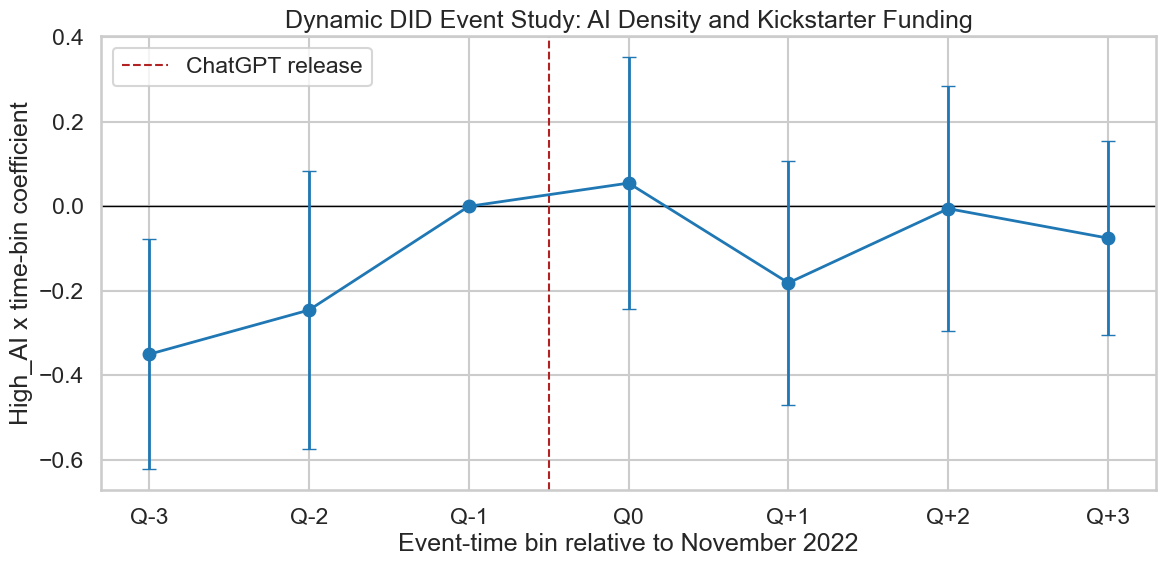

Interpretation guide: pre-period coefficients should be statistically close to zero for parallel trends.
Post-period coefficients show the divergence in log pledged amount for high-AI projects after ChatGPT.


In [25]:
# Step 5: Plot the event-study coefficients and 95% confidence intervals
plot_df = event_coefs.copy()
plot_df['x'] = np.arange(len(plot_df))
plot_df['err_low'] = plot_df['coef'] - plot_df['ci_low']
plot_df['err_high'] = plot_df['ci_high'] - plot_df['coef']

fig, ax = plt.subplots(figsize=(12, 6))
ax.axhline(0, color='black', linewidth=1)
ax.axvline(EVENT_BIN_ORDER.index('Q0') - 0.5, color='firebrick', linestyle='--', linewidth=1.5, label='ChatGPT release')
ax.errorbar(
    plot_df['x'],
    plot_df['coef'],
    yerr=[plot_df['err_low'], plot_df['err_high']],
    fmt='o-',
    color='#1f77b4',
    ecolor='#1f77b4',
    capsize=5,
    linewidth=2,
)
ax.set_xticks(plot_df['x'])
ax.set_xticklabels(plot_df['time_bin'])
ax.set_xlabel('Event-time bin relative to November 2022')
ax.set_ylabel('High_AI x time-bin coefficient')
ax.set_title('Dynamic DID Event Study: AI Density and Kickstarter Funding')
ax.legend()
plt.tight_layout()
plt.show()

print('Interpretation guide: pre-period coefficients should be statistically close to zero for parallel trends.')
print('Post-period coefficients show the divergence in log pledged amount for high-AI projects after ChatGPT.')

## 6. Causal Mediation: Comment Sentiment as a Mechanism

This section tests whether analyzed comment sentiment is a plausible mechanism linking high AI density after ChatGPT to funding outcomes. Path A estimates whether `High_AI x PostGPT` changes mean project-level comment sentiment. Path B/C estimates whether comment sentiment predicts funding while controlling for the direct `High_AI x PostGPT` effect.

In [23]:
# Step 6: Mediation-style regressions for the comment sentiment mechanism
mediation_sample = df_analysis.dropna(subset=['comment_sentiment']).copy()
print(f'Mediation sample: {len(mediation_sample):,} projects with analyzed comment sentiment')

path_a_formula = (
    "comment_sentiment ~ High_AI * PostGPT + text_quality + log_goal + C(category_unified)"
)
path_bc_formula = (
    "log_pledged_amount ~ High_AI * PostGPT + comment_sentiment "
    "+ text_quality + log_goal + C(category_unified)"
)

path_a_model = smf.ols(path_a_formula, data=mediation_sample).fit(cov_type='HC3')
path_bc_model = smf.ols(path_bc_formula, data=mediation_sample).fit(cov_type='HC3')

print('\n--- Path A: Does High_AI x PostGPT shift comment sentiment? ---')
print(path_a_model.summary())

print('\n--- Path B/C: Does comment sentiment explain funding after controlling direct DID? ---')
print(path_bc_model.summary())

direct_effect = path_bc_model.params.get('High_AI:PostGPT', np.nan)
sentiment_effect = path_bc_model.params.get('comment_sentiment', np.nan)
path_a_effect = path_a_model.params.get('High_AI:PostGPT', np.nan)
print('\nKey quantities:')
print(f'Path A interaction effect on comment sentiment: {path_a_effect:.4f}')
print(f'Direct High_AI x PostGPT effect net of comment sentiment: {direct_effect:.4f}')
print(f'Association between comment sentiment and log pledged amount: {sentiment_effect:.4f}')

Mediation sample: 8,138 projects with analyzed comment sentiment

--- Path A: Does High_AI x PostGPT shift comment sentiment? ---
                            OLS Regression Results                            
Dep. Variable:      comment_sentiment   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     61.05
Date:                Wed, 20 May 2026   Prob (F-statistic):          1.79e-142
Time:                        23:50:55   Log-Likelihood:                -261.22
No. Observations:                8138   AIC:                             548.4
Df Residuals:                    8125   BIC:                             639.5
Df Model:                          12                                         
Covariance Type:                  HC3                                         
                                                    coef    std err          z  

## Notes on Interpretation

- The event-study plot is the main credibility check. If `Q-3` and `Q-2` are far from zero or precisely estimated in opposite directions, the DID design is suspect.
- `Q-1` is intentionally omitted because it is strictly before ChatGPT and closest to the shock.
- The mediation regressions are mechanism evidence, not a full sequential-ignorability proof. Treat them as suggestive unless additional assumptions are defended.

## 7. Longitudinal Daily DID on Comment Sentiment

While Path A above tests sentiment averaged over the lifetime of a project *cross-sectionally*, this longitudinal analysis constructs a panel at the **project-day** level.

Here, `PostGPT_Date` varies by the actual date of each comment. This allows us to observe if projects with `High_AI` see a distinct break in daily backer sentiment immediately after the release of ChatGPT.

In [2]:
# Step 7: Longitudinal Daily DID on Comment Sentiment
print("Building daily longitudinal comments panel...")

# 1. Parse comment dates and bin to the day level
comments_long = comments.copy()
comments_long['date'] = pd.to_datetime(
    comments_long['created_at'], 
    utc=True, 
    errors='coerce'
).dt.tz_localize(None).dt.floor('D')

# 2. Aggregate sentiment to the (project_id, date) level
daily_comments = (
    comments_long.dropna(subset=['date', 'comment_sentiment'])
    .groupby(['project_id', 'date'], as_index=False)
    .agg(
        daily_sentiment=('comment_sentiment', 'mean'),
        daily_comment_count=('comment_sentiment', 'size')
    )
)

# 3. Create time treatment (1 if the comment was posted after ChatGPT)
daily_comments['PostGPT_Date'] = (daily_comments['date'] >= CHATGPT_RELEASE).astype(int)

# 4. Merge cross-sectional project traits (High_AI, controls) from the clean sample
project_traits = df_analysis[['project_id', 'High_AI', 'text_quality', 'log_goal', 'category_unified']].copy()
panel_df = daily_comments.merge(project_traits, on='project_id', how='inner')

print(f"Daily Panel: {len(panel_df):,} project-day observations from {panel_df['project_id'].nunique():,} projects")

# 5. Fit Longitudinal DID Regression (clustering standard errors by project_id)
panel_formula = (
    "daily_sentiment ~ High_AI * PostGPT_Date + text_quality + log_goal + C(category_unified)"
)

print("\n--- Longitudinal Daily DID: High_AI x PostGPT on daily sentiment ---")
try:
    panel_model = smf.ols(panel_formula, data=panel_df).fit(
        cov_type='cluster', 
        cov_kwds={'groups': panel_df['project_id']}
    )
    print(panel_model.summary())
except Exception as e:
    print(f"Model failed to fit: {e}")

Building daily longitudinal comments panel...


NameError: name 'comments' is not defined

In [ ]:
# Step 7: Longitudinal Daily DID on Comment Sentiment
print("Building daily longitudinal comments panel...")

# 1. Parse comment dates and bin to the day level
comments_long = comments.copy()
comments_long['date'] = pd.to_datetime(
    comments_long['created_at'], 
    utc=True, 
    errors='coerce'
).dt.tz_localize(None).dt.floor('D')

# 2. Aggregate sentiment to the (project_id, date) level
daily_comments = (
    comments_long.dropna(subset=['date', 'comment_sentiment'])
    .groupby(['project_id', 'date'], as_index=False)
    .agg(
        daily_sentiment=('comment_sentiment', 'mean'),
        daily_comment_count=('comment_sentiment', 'size')
    )
)

# 3. Create time treatment (1 if the comment was posted after ChatGPT)
daily_comments['PostGPT_Date'] = (daily_comments['date'] >= CHATGPT_RELEASE).astype(int)

# 4. Merge cross-sectional project traits (High_AI, controls) from the clean sample
project_traits = df_analysis[['project_id', 'High_AI', 'text_quality', 'log_goal', 'category_unified']].copy()
panel_df = daily_comments.merge(project_traits, on='project_id', how='inner')

print(f"Daily Panel: {len(panel_df):,} project-day observations from {panel_df['project_id'].nunique():,} projects")

# 5. Fit Longitudinal DID Regression (clustering standard errors by project_id)
panel_formula = (
    "daily_sentiment ~ High_AI * PostGPT_Date + text_quality + log_goal + C(category_unified)"
)

print("\n--- Longitudinal Daily DID: High_AI x PostGPT on daily sentiment ---")
try:
    panel_model = smf.ols(panel_formula, data=panel_df).fit(
        cov_type='cluster', 
        cov_kwds={'groups': panel_df['project_id']}
    )
    print(panel_model.summary())
except Exception as e:
    print(f"Model failed to fit: {e}")